# 📊 03. 데이터 통계 + 인사이트 리포트 — H&M 커머스

> 엔코아 AI캠퍼스 · 데이터 분석 & AI 머신러닝 캠프

이 노트북은 **01_데이터이해_전처리 → 02_데이터_EDA → 03_데이터_통계(이 노트북)** 3파트 파이프라인의 **마지막**입니다. 02 에서 관찰만 하고 넘긴 질문("이 차이가 우연인지")을 여기서 통계로 확인하고, 프로젝트를 **인사이트 리포트**로 마무리합니다.

**구성**
1. **정제본 불러오기** — 01 이 만든 표를 그대로 이어 씁니다. 맨 위 선언 셀에서 라이브러리와 폰트를 한 번 준비해 두면 끝까지 씁니다. **어떤 함수를 쓸지는 day08·09 교안과 공식 문서에서 직접 찾으세요.**
2. **선택 통계 미션 카탈로그** — ⚠️ **통계는 필수가 아닙니다.** 발제문의 필수 목표는 EDA·시각화·인사이트입니다. 이 절은 "차이가 우연인지까지 따지고 싶은 사람"을 위한 **선택**이며, **2~3개만 골라도 충분**합니다.
3. **최종 인사이트 리포트** — 이 프로젝트의 마무리, **필수**입니다.
4. **AI 협업 검증** — 오류가 심어진 AI 초안을 실제로 재계산해 잡아내는 실습입니다.
5. **제출 체크리스트** — 발제문 필수 목표를 다 담았는지 스스로 확인합니다.

## 1. 정제본 불러오기
01 이 저장한 정제본(`output/hm_clean.csv`)을 읽습니다. **원본 3개 테이블은 다시 읽지 않습니다.**

### 준비 ① 도구 챙기기 — 어떤 라이브러리를 왜 쓰나
이 노트북은 **코드를 주지 않습니다.** 각 절이 *무엇을* 해야 하는지와 *어떤 도구*를 쓰는지 알려 주니, 코드는 그것을 보고 **직접** 쓰세요. 아래 표의 도구를 **바로 다음 셀에서 한 번만 선언**해 두면 끝까지 씁니다 — 뒤 절에서는 다시 import 하지 않습니다.

| 무엇에 쓰나 | 어떤 도구(관례 별칭) |
| --- | --- |
| 표·집계·수치 | `pandas`(`pd`) · `numpy`(`np`) |
| 그림 | `matplotlib.pyplot`(`plt`) · `seaborn`(`sns`) |
| 추정·카이제곱 적합도 | `scipy` 의 `stats` |
| 가정 점검·검정·효과크기·사후검정 | `pingouin`(`pg`) |
| 비모수 사후검정(Dunn) | `scikit_posthocs`(`sp`) — pingouin 에 없습니다 |
| 회귀·잔차 진단 | `statsmodels` 의 `formula.api`(`smf`)·`durbin_watson`·`het_breuschpagan` |
| 카이제곱 사후분석(조정된 잔차) | `statsmodels` 의 `Table` |

**한글 폰트**도 여기서 정해 두세요 — 안 하면 그래프의 한글이 □□□ 로 깨집니다. `platform.system()` 으로 OS 를 보고 Windows 는 `'Malgun Gothic'`, macOS 는 `'AppleGothic'`, 리눅스·Colab 은 `'NanumGothic'` 을 `plt.rcParams['font.family']` 에 넣고, `plt.rcParams['axes.unicode_minus']` 를 `False` 로 두어 마이너스 부호 깨짐도 막습니다. `sns.set_theme(...)` 은 폰트 설정을 되돌리므로 **set_theme 에 `font=` 로 같은 폰트를 넘기거나, set_theme 뒤에 폰트를 다시 지정**하세요. 01·02 의 준비 셀과 같은 내용이라 그대로 가져와도 됩니다.

> 🔧 **막히면**: 경고 메시지가 너무 많으면 `warnings.filterwarnings('ignore')` 로 눌러 둘 수 있습니다(통계 라이브러리는 참고용 경고를 자주 냅니다).

In [73]:
# ── 이 노트북에서 쓸 도구를 여기서 한 번만 선언합니다 (뒤 절에서 다시 import 하지 않습니다) ──
#   pandas(pd) · numpy(np) · matplotlib.pyplot(plt) · seaborn(sns)
#   scipy 의 stats · pingouin(pg) · scikit_posthocs(sp)
#   statsmodels.formula.api(smf) · durbin_watson · het_breuschpagan · Table
#   한글 폰트: platform.system() 으로 OS 판별 -> plt.rcParams['font.family'],
#             plt.rcParams['axes.unicode_minus'] = False,
#             sns.set_theme(..., font=<같은 폰트>) 로 되돌림 방지

# 여기에 코드를 작성하세요
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import stat 
import os
import platform
import warnings
import pingouin as pg   
from scipy import stats
from scipy import stats             # 보조 통계 함수
import statsmodels.formula.api as smf          # 회귀분석 (smf.ols)
from statsmodels.stats.stattools import durbin_watson   # 잔차 독립성 지표
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns' , 40)
if platform.system() == 'Windows':
    KOREAN_FONT = 'Malgun Gothic'
    FONT_PATH = 'C:/Windows/Fonts/malgun.ttf'
elif platform.system() == 'Darwin':   
    KOREAN_FONT = 'AppleGothic'
    FONT_PATH = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
else:                                    
    KOREAN_FONT = 'NanumGothic'
    FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

plt.rcParams['font.family'] = KOREAN_FONT
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid' , font=KOREAN_FONT)
rc={'axes.unicode_minus': False}
#

### 준비 ② 정제본을 `df` 라는 이름으로 불러오기
- **무엇을**: 01 이 저장한 정제본 `output/hm_clean.csv` 를 `pd.read_csv` 로 읽습니다. **변수명은 `df`** 로 두세요 — 이 노트북의 모든 지침이 `df` 를 가정합니다. 읽은 뒤 `df.shape` 와 `df.head()` 로 무엇이 들어왔는지 먼저 확인합니다(데이터를 보지 않고 검정부터 하지 않습니다).
- **필요한 컬럼**: `t_dat`(거래일) · `age` · `price` · `sales_channel_id` · `club_member_status` · `product_group_name` · `customer_id`. 하나라도 없으면 **01 로 돌아가** 그 컬럼을 남긴 채 다시 저장하세요(원본 3개 테이블을 여기서 다시 읽지는 않습니다).
- **날짜형 복구**: CSV 를 거치면 `t_dat` 가 문자열로 풀립니다 → `pd.to_datetime` 으로 되돌리세요. 안 하면 뒤에서 `.dt` 접근이 실패합니다.
- **파생 컬럼(이름 그대로 만드세요)**: `month` = `t_dat` 의 월(`.dt.month`), `age_group` = 10년 단위 연령대(`age // 10 * 10`, 정수형). 요일까지 보고 싶으면 `weekday`(`.dt.dayofweek`)를 더해도 됩니다. 무거운 그림·계산에 쓸 표본이 필요하면 `df_s` 를 하나 만들어 두면 편합니다(3000행, `random_state=42` 로 고정하면 매번 같은 표본).

> ⚠️ **정제 규칙이 기준값을 바꿉니다** — 이 노트북에 적어 둔 기대값(예: 채널 t≈64.9, 4절 자가채점의 74.7%)은 **01 의 표준 규칙**을 적용한 **113,218행** 기준입니다: 중복 제거 · 나이 10~99세만 남김 · `price > 0` · `sales_channel_id` 는 `isin([1, 2])`(정의에 없는 코드 `0` 제외) · `club_member_status` 결측은 `fillna('Unknown')`. 여러분이 다른 규칙을 골랐다면 숫자가 조금씩 다를 수 있고 **그건 틀린 게 아닙니다**(01 에 이유를 적어 두었다면). 다만 **4절 자가채점만은** 위 규칙에 맞춰 두세요.

In [74]:
# ── 쓸 도구 ─────────────────────────────────────────
#   pd.read_csv('output/hm_clean.csv') -> 변수명은 df (이 노트북의 모든 지침이 df 를 가정)
df = pd.read_csv('./output/hm_clean.csv')
df[['month','age_group']]
df_s = df.sample(n=3000 , random_state=42)
df.shape #(114597, 37)
df.head()
#   pd.to_datetime(df['t_dat'])  — CSV 를 거치면 문자열로 풀립니다
#   파생: month = .dt.month · age_group = age // 10 * 10 (정수형)
#   무거운 계산용 표본: df_s = df.sample(n=3000, random_state=42)
#   확인: df.shape · df.head()

# 여기에 코드를 작성하세요

,t_dat,customer_id,article_id,price,sales_channel_id,FN,Active,club_member_status,fashion_news_frequency,age,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc,month,weekday,age_group
0,2019-01-01,80d8c96835c3aaf25a5b2bc306d9747bbd4601fd75bc65...,542677002,0.050831,2,0,0,ACTIVE,NONE,30,542677,Stetson SP Body Andes,283,Underwear body,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1338,Expressive Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Body in lace and mesh with underwired, thickly...",1,Tuesday,30
1,2019-01-01,a105c61ed98470b3dbed27f1bdfc584d09d20762efe680...,665201002,0.010153,2,1,1,ACTIVE,Regularly,21,665201,RA shorts conscious,274,Shorts,Garment Lower body,1010016,Solid,63,Dark Purple,4,Dark,6,Lilac Purple,8310,Ladies Sport Bottoms,S,Sport,26,Sport,5,Ladies H&M Sport,1005,Jersey Fancy,Short sports shorts in fast-drying functional ...,1,Tuesday,20
2,2019-01-01,05e0e58672ee73b047e510dbf974ce1870f92b71f5f6ac...,629061002,0.089983,2,0,0,ACTIVE,NONE,35,629061,Rachel jumper,252,Sweater,Garment Upper body,1010010,Melange,7,Grey,2,Medium Dusty,12,Grey,1612,Jersey/Knitwear Premium,A,Ladieswear,1,Ladieswear,14,Womens Premium,1003,Knitwear,"Jumper in soft, fine-knit cashmere with long, ...",1,Tuesday,30
3,2019-01-01,09a33e5dab855528c7dad33a4119b68102aa91c37a9e25...,554704005,0.030492,2,1,1,ACTIVE,Regularly,58,554704,Polka Blazer TW,264,Blazer,Garment Upper body,1010010,Melange,8,Dark Grey,2,Medium Dusty,12,Grey,1244,Outdoor/Blazers,D,Divided,2,Divided,53,Divided Collection,1007,Outdoor,Long jacket in jersey with narrow notch lapels...,1,Tuesday,50
4,2019-01-01,58bb1e01b9e8e592bef5ea8e2dbe587fc3ca290b55e976...,572400002,0.023712,2,0,0,Unknown,NONE,46,572400,Taya Hood,308,Hoodie,Garment Upper body,1010010,Melange,7,Grey,1,Dusty Light,12,Grey,1643,Basic 1,D,Divided,2,Divided,51,Divided Basics,1002,Jersey Basic,Long-sleeved top in sweatshirt fabric with a j...,1,Tuesday,40


## 2. 선택 통계 미션 카탈로그
⚠️ **다시 한 번 — 통계는 필수가 아닙니다.** 발제문의 필수 목표는 EDA·시각화·인사이트입니다. 아래 미션은 **검정을 스스로 고르고 함수를 직접 찾아** 해 보는 연습이며, **2~3개만 골라도 충분**합니다.

| # | 미션 | 난이도 | 도구 | 예상 시간 |
| --- | --- | --- | --- | --- |
| A | 채널별 단가 차이 검정 | ★★ | `pg.homoscedasticity`·`pg.ttest` | 15분 |
| B | 연령대별 단가 차이 + 사후검정 *(02 연계)* | ★★★ | `pg.anova`/`welch_anova`·사후검정 | 20분 |
| C | 연령대 × 채널 독립성 검정 *(02 연계)* | ★★★ | `pg.chi2_independence`·조정잔차 | 20분 |
| D | 멤버십별 단가 차이 검정 | ★★★ | `pg.anova`·`pg.pairwise_tukey` | 20분 |
| E | 고객 총구매액 회귀 + LINE 진단 | ★★★ | `smf.ols`·잔차 진단 | 25분 |

### 미션 A — 채널별 단가 차이 검정
온라인·오프라인의 평균 단가가 정말 다른지 **가정 점검 → 검정 선택 → 실행**의 전 과정을 **직접** 작성해 보세요 — 가정 점검부터 검정 선택까지 스스로 판단해야 합니다.

> ✅ **이런 결과면 잘 된 것**: 등분산 점검 결과에 맞는 t-검정을 고르면 T 값이 약 64.9 근처로 나옵니다.
> 🔧 **막히면 볼 곳**: day08·09 교안에서 해당 검정을 찾아보세요 — (가정 점검)·(t-검정)

In [ ]:
# 여기에 코드를 작성하세요
#가정 점검 ->t검정을 사용하고 온라인 오프라인시 평균 단가가 무조건 다를것이다
#검정 t-검정 온라인 오프라인인 --> df['channel] , 평균 단가 -->price 를 사용해서
df['channel'] = df['sales_channel_id'].map({
    2 : '온라인' , 
    1 : '오프라인'
})

channel = pg.homoscedasticity(data = df , dv='price', group='channel') 
#pval이 0.5보다 작고 False
online = df.loc[df['sales_channel_id'] == 2, 'price']
offline = df.loc[df['sales_channel_id'] == 1, 'price']

result = pg.ttest(
    online,
    offline,
    paired=False,
    correction=True
)
#온라인103,836건 vs 오프라인 45,861건
result
#t값이 양수이므로 온라인이 오프라인보다 평균단가 높다
#pval은 작게 나와서 유의한 차이가 있다
#효과크기는 중간수준 하지만 표본의 차이가 심하기 떄문에 무조건 온라인이
#우세하다는 함정에 빠지기 쉽다

,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,64.317778,87646.254585,two-sided,0.0,"[0.01, 0.01]",0.370911,1.0,inf


### 미션 B — 연령대별 단가 차이 + 사후검정
02 의 질문 — "연령대별 평균 단가 차이가 통계적으로 유의한가?" — 를 **직접** 검정하세요. 정규성·등분산을 점검하고, 그 결과에 맞는 ANOVA(또는 Welch-ANOVA)와 사후검정을 실행하세요.

> ✅ **이런 결과면 잘 된 것**: F 값이 약 55(Welch) 근처, η² 는 0.01 미만(매우 작음)으로 나오고, 사후검정에서 36쌍 중 절반가량이 유의하게 나오면 됩니다.
> 🔧 **막히면 볼 곳**: day08·09 교안에서 해당 검정을 찾아보세요 — (가정 점검 선택표)·(ANOVA/Welch-ANOVA)

In [ ]:
# 여기에 코드를 작성하세요
# 연령대별 단가 차이 pg.anova ,welch.anova
df['age_group']
display(pg.normality(data=df, dv='price', group='age_group'))

display(pg.homoscedasticity( data=df, dv='price',   group='age_group'))
#등분산결과가 False이므로 anova와 gameshowell 선택
aov  = pg.anova(data = df , dv='price' , between='age_group',detailed=True)
print(aov) #F=52.67.. p=7.318685e-86 0.05보다 작음  np2 =0.003664 효과크기가 작다
#연령대별 통계적으로는 유의한 차이기 있지만 사실은 효과크기 미미하다
print()
aov_1 = pg.welch_anova(data = df ,dv='price' , between='age_group')
print(aov_1) #F = 55.123447  p_unc=6.041641e np2 =0.003664
print()
pg_game=pg.pairwise_gameshowell(data=df , dv='price' , between='age_group')
(pg_game['pval']<0.05).sum() #17개라 절반 이상 나온다

,W,pval,normal
age_group,,,
30,0.788871,7.725599e-98,False
20,0.850718,7.698285e-106,False
50,0.782554,9.868732e-94,False
40,0.800288,5.772553e-90,False
60,0.809263,1.082561e-58,False
10,0.883408,4.969419e-36,False
70,0.789542,2.478785e-30,False
80,0.923566,8.664764e-04,False
90,0.929675,5.775925e-01,True


,W,pval,equal_var
levene,22.604753,7.338056e-35,False


      Source         SS      DF        MS          F         p_unc       np2
0  age_group   0.155606       8  0.019451  52.670235  7.318685e-86  0.003664
1     Within  42.316434  114588  0.000369        NaN           NaN       NaN

      Source  ddof1       ddof2          F         p_unc       np2
0  age_group      8  122.089252  55.123447  6.041641e-37  0.003664



np.int64(17)

### 미션 C — 연령대 × 채널 독립성 검정
02 의 두 번째 질문 — "연령대와 채널 선호가 독립적인가?" — 를 카이제곱 독립성 검정으로 확인하세요. **기대빈도가 5 이상인지** 먼저 확인하고, 부족하면 연령대를 묶어 다시 검정하세요. Cramér's V 와 조정된 잔차까지 확인하세요.

> ✅ **이런 결과면 잘 된 것**: 그룹핑 후 최소 기대빈도가 5 이상이 되고, χ² 는 유의(p≈0)하지만 Cramér's V 는 0.1 미만(약함)으로 나오면 됩니다.
> 🔧 **막히면 볼 곳**: day08·09 교안에서 해당 검정을 찾아보세요 — (카이제곱)

In [ ]:
# 여기에 코드를 작성하세요
#`pg.chi2_independence`·조정잔차
df['age_group_8090'] = df['age_group'].replace({90: 80})
expected , observed , chi_stats = pg.chi2_independence(data=df , x ='channel',y='age_group')

display(expected)
display(observed)
display(chi_stats)
#일단 pavl < 0.05 이므로 연령대와 채널의 이용은 관련이 있고
#cramer = 0.079라서 관련성의 크기가 매우 작이 이 이유는 
# 첫번째 페이지에서 온라인의 표본수가 매우많고 오프라인의 표본가 매우 적었기 때문이지
#  않을까 라는 생각이 든다 온라인 103,836건 vs 오프라인 45,861건

age_group_8090,10,20,30,40,50,60,70,80
channel,,,,,,,,
오프라인,595.889179,14366.525293,7140.215956,5446.021231,5856.809643,1386.718369,234.911937,20.908392
온라인,1342.110821,32357.474707,16081.784044,12265.978769,13191.190357,3123.281631,529.088063,47.091608


age_group_8090,10,20,30,40,50,60,70,80
channel,,,,,,,,
오프라인,844,14086,5847,5878,6475,1584,315,19
온라인,1094,32638,17375,11834,12573,2926,449,49


,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,719.205950,7.0,4.982136e-151,0.079221,1.0
1,cressie-read,0.666667,718.249025,7.0,8.012494e-151,0.079168,1.0
2,log-likelihood,0.000000,717.940164,7.0,9.340503e-151,0.079151,1.0
3,freeman-tukey,-0.500000,719.069772,7.0,5.330664e-151,0.079213,1.0
4,mod-log-likelihood,-1.000000,721.334985,7.0,1.731019e-151,0.079338,1.0
5,neyman,-2.000000,729.203374,7.0,3.478962e-153,0.079770,1.0


### 미션 D — 멤버십별 단가 차이 검정
채널·연령대와는 다른 축인 **멤버십 상태(`club_member_status`)** 별로 단가가 다른지 검정하세요. 이번엔 등분산이 만족되는 경우인지 직접 확인해 보세요(은 연령대만 다뤘습니다).

> ✅ **이런 결과면 잘 된 것**: 등분산이 만족되어 일반 ANOVA를 쓰면 F 는 약 9 근처, p 는 유의하지만 η² 는 0.001 미만(극히 작음)으로 나오고, 사후검정에서는 딱 한 쌍만 유의하게 나오면 됩니다.
> 🔧 **막히면 볼 곳**: day08·09 교안에서 해당 검정을 찾아보세요 — (가정 점검)·(ANOVA)

In [78]:
# 여기에 코드를 작성하세요

### 미션 E — 고객 총구매액 회귀 + LINE 진단
고객별 총구매액을 나이·구매빈도·온라인비중으로 설명하는 **다중회귀**를 적합하고, LINE 4가정을 잔차로 진단하세요(지침대로 만든 `cust`·`m_multi` 를 그대로 이어 써도 됩니다).

> ✅ **이런 결과면 잘 된 것**: R² 는 약 0.38, 세 계수 모두 p<0.001 로 유의하고, Durbin-Watson 은 2 근처(독립성 OK)지만 Breusch-Pagan p 는 사실상 0(등분산 위배)으로 나오면 됩니다.
> 🔧 **막히면 볼 곳**: day08·09 교안에서 해당 검정을 찾아보세요 — (회귀·LINE 진단)

In [79]:
# 여기에 코드를 작성하세요

## 3. 최종 인사이트 리포트 (필수)
여기부터는 **선택이 아닙니다.** 01→02→03 에서 본 것을 하나의 리포트로 묶는, 이 프로젝트의 마무리입니다.

**리포트 뼈대 — 다섯 조각**
1. **무엇을 물었나** — 이 분석의 질문·가설(00 에서 세운 비즈니스 목표와 연결).
2. **어떻게 봤나** — 데이터·처리 규칙 요약(무엇을 지우고 무엇을 남겼는지, 그 이유).
3. **무엇을 발견했나** — 수치 + 그래프로 뒷받침되는 핵심 발견 2~4개(통계를 했다면 p·효과크기도).
4. **그래서 무엇을 하나** — 발견을 실행 가능한 제안으로(누구에게·무엇을·어떻게).
5. **한계** — 이 결론을 과신하면 안 되는 이유.

**숫자를 말로 옮기는 법** — ③ 발견을 쓸 때는 항상 이 순서를 따르세요.
1. **숫자 재진술** — 무엇을 비교했고 값이 얼마였는지 있는 그대로 적는다.
2. **유의성 + 효과크기** — p-value(우연인지)와 Cohen's d·η²·Cramér's V(크기)를 함께 적는다.
3. **방향** — 그래서 무엇이 더/덜 한지 한 문장으로 정리한다.

이때 두 가지를 절대 헷갈리지 마세요 — **유의 ≠ 실질**(p 가 작다고 차이가 큰 것은 아님, 특히 표본이 클 때)과 **상관 ≠ 인과**(같이 움직인다고 한쪽이 다른 쪽의 원인은 아님)입니다.

**좋은 예 / 나쁜 예**

| | 나쁜 예 | 좋은 예 |
| --- | --- | --- |
| 발견 | "온라인이 잘 팔린다" | "온라인 평균 단가가 오프라인보다 **약 1.3배**(0.0299 vs 0.0228) 높고, 이 차이는 통계적으로 유의하며 효과크기(Cohen's d=0.376)도 작은~중간 수준이다." |
| 제안 | "마케팅을 더 하자" | "단가가 높은 온라인 채널에 매출 상위 상품군(상의류) 노출을 강화하고, 가입 대기(PRE-CREATE) 고객 대상 온라인 온보딩을 설계한다." |
| 한계 | (언급 없음) | "이 데이터는 **Kaggle 이 공개한 표본**이라 전체 H&M 고객이 아니고, **관찰 자료라 인과가 아니며**, `price` 는 실제 화폐가 아닌 **정규화된 상대값**이다." |

**한계·해석 규율 — 어떤 결론을 쓰든 빠뜨리면 안 되는 여섯 가지**
- **매출의 정의(수량이 없다)**: 거래 표에 **수량(quantity) 컬럼이 없습니다.** 그래서 `price` 를 더한 값은 엄밀히 "매출액"이 아니라 **"구매 단가의 총합"** 입니다 — 리포트에 이 말을 그대로 적어 두세요. 게다가 이 값은 실제 화폐가 아니라 **0~1 사이로 정규화된 상대값**입니다(직접 `df['price'].min()`·`max()`·`mean()` 으로 확인해 보세요). "1,000원"처럼 절대 금액으로 읽거나 통화 단위를 붙여 쓰면 안 됩니다. 참고로 발제문에는 통화 단위를 언급하라고 적혀 있지만 이 데이터의 `price` 는 그 서술과 맞지 않습니다 — **문서와 데이터가 다를 때는 데이터를 믿고, 그 차이를 리포트에 적으세요.**
- **표본 편향**: 이 데이터는 Kaggle 이 공개한 **일부 표본**입니다 — 특히 **온라인(`sales_channel_id=2`) 기록이 상대적으로 많이 담겨** 있어 채널 비중이 실제보다 온라인 쪽으로 왜곡돼 있을 수 있습니다. 그래서 채널·집단을 비교할 때는 **건수 그대로가 아니라 비율(%)이나 고객당 평균 구매액(ARPU)으로 보정**해 비교하세요.
- **상관 ≠ 인과**: 연령대·채널·멤버십과 단가 사이의 관계는 원인이 아니라 **관찰된 결과**입니다. "20대 단가가 높다 → 20대를 집중 타깃으로" 같은 도약을 하지 마세요(무작위 배정 실험이 아니므로 "온라인이라서 비싸졌다"도 말할 수 없습니다). 제안은 "이 세그먼트에서 **검증해 볼 가치가 있다**" 수준으로 씁니다.
  · 참고로 발제문은 이 대목에서 **성별**을 예로 들며 "20대 여성" 을 언급하지만, 이 데이터의 고객 테이블에는 **성별 컬럼이 아예 없습니다**(`customer_id`·`FN`·`Active`·`club_member_status`·`fashion_news_frequency`·`age` 6개). 발제문에 적힌 변수가 실제로 있는지 **직접 확인하고** 없으면 "이 표본에는 성별 정보가 없어 분석하지 못했다"고 한계에 적으세요.
- **시즌성**: 특정 월의 급증을 **"성장"으로 단정하지 마세요.** 블랙프라이데이·연말연시 같은 이벤트가 반영돼 있을 수 있습니다. 추세를 말하려면 여러 기간을 비교하거나 롤링 평균처럼 노이즈를 줄인 뒤 말하세요.
- **인기 ≠ 트렌드 선도**: 상품군·색상의 매출 상위는 **공급량·재고 정책·프로모션**의 결과일 수 있습니다. "상의류가 1위"는 사실이지만 "상의류가 트렌드를 이끈다"는 이 데이터로 말할 수 없습니다.
- **인플레이션·환율 미반영**: 시점별 물가·환율 차이가 보정되지 않았으므로 **절대적 추세 해석은 제한적**입니다 — 같은 시점 안에서의 **상대 비교**에 초점을 두세요.

**리포트 템플릿** — 아래 빈칸을 채우세요.

frequency
미구독    64800
구독     49797
Name: count, dtype: int64


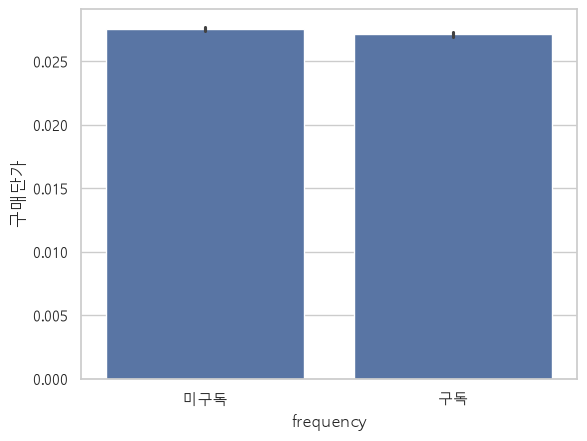

,W,pval,equal_var
levene,2.269115,0.131979,True


,count,mean
frequency,,
구독,40104,0.027126
미구독,53912,0.027562


,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-3.612998,94014,two-sided,0.000303,"[-0.0, -0.0]",0.023825,0.950834,5.077


In [106]:
# 코드가 아니라 서술입니다 — 아래 마크다운 셀에 리포트를 작성하세요.
df['frequency'] = df['fashion_news_frequency'].map({
    'NONE': '미구독',
    'Regularly': '구독',
    'Monthly': '구독'
})
print(df['frequency'].value_counts(dropna=False))
sub_news = df.groupby(['customer_id' , 'frequency']).agg(
    구매단가 = ('price' , 'mean')
).reset_index()
sub_news
sns.barplot(data=sub_news , x='frequency' , y='구매단가')
plt.show()
#별 차이가 나지 않아 보인다
sub_dif = pg.homoscedasticity(data = sub_news , dv='구매단가', group='frequency') 
#pval이 0.5보다 작고 False
display(sub_dif)
#p-value = 0.1403 > 0.05
#p-value가 0.05보다 크고 equal_var=True이므로 등분산 가정을 만족
#분산이 비슷하다

display(  sub_news.groupby('frequency')['구매단가'].agg(
    ['count', 'mean']))
no_sub = sub_news.loc[sub_news['frequency']== '미구독' , '구매단가']
yse_sub = sub_news.loc[sub_news['frequency']== '구독' , '구매단가']
display(pg.ttest(yse_sub, no_sub, paired=False, correction=False))
#p-value가 0.000372 < 0.05 가 나름 유의한 차이가 있다고 나와는 있지만
# Cohen's d 0.023효과크기가 매우 미미하기 떄문에 실제의 차이는 매우 작다
#power 0.945 로 1에 매우 근접하기 떄문에 검정령은 충분하다고 볼 수있따





 *(① 무엇을 물었나)*
- 패션 뉴스 구독 여부에 따른 고객의 평균 구매단가에 대한 차이가 있는가
*(② 어떻게 봤나 — 데이터·처리 규칙 요약)*
- fashion_news_frequency에서 NONE은 미구독, 나머지는 구독으로 구분하고 
 평균 구매단가를 계산한다
*(③ 무엇을 발견했나 — 수치+그래프 근거, 통계를 했다면 p·효과크기도)*
- 미구독 고객의 평균 구매단가는 약 0.02774, 구독 고객은 약 0.02732로 구독 고객이 조금 낮았다. t검정 결과 p-value는 약 0.0004로 통계적으로 유의했지만, Cohen's d는 약 0.023으로 효과크기가 매우 작았다. 따라서 구독 여부에 따른 실제 구매단가 차이는 거의 없다고 볼 수 있다.
*(④ 그래서 무엇을 하나 — 실행 가능한 제안)*
- 유의미한 것은 있지만 그 효과가 매우적기 때문에 구독 미구독 여부에 따라서 고객을 나눠서 마케팅을 하는것보다는 뉴스의 발송회수나 레터 같은 겉은로 비교 분석을 하는것이 필요하다 느낌
*(⑤ 한계 — 위 여섯 가지(매출의 정의·표본 편향·상관≠인과·시즌성·인기≠트렌드·물가·환율)를 반드시 포함)* - 
- 온라인 거래가 많이 포함된 표본이라 전체 고객을 대표한다고 보기 어렵고 구독 고객의 구매단가가 다르다고 해서 뉴스 구독이 원인이라고 말할 수는 없다. 데이터가 1년치라 계절이나 특정 이벤트의 영향을 장기적인 변화로 판단하기 어렵고, 많이 팔린 상품이 있다고 해도 재고나 프로모션의 영향일 수 있어 트렌드를 이끈다고 단정할 수 없다. 마지막으로 물가와 환율이 반영되지 않았기 때문에 시점별 가격을 절대적인 금액으로 비교하는 데도 한계가 있다.

## 4. AI 협업 검증
리포트 초안 작성에 AI(챗봇형 도구)를 쓰면 빠르지만, AI 는 **숫자·인과·연관 강도를 그럴듯하게 지어내거나 과장할 수 있습니다(환각)**. 여기서는 실제 API 호출 없이, **이미 오류가 심어진 AI 초안을 직접 재계산해 잡아내는 연습**을 합니다.

**① 좋은 프롬프트 4요소** — 맥락(무슨 데이터·무슨 분석인지) + 수치(내가 가진 정확한 값) + 요청(무엇을 써 달라는지) + 형식(불릿·길이 등), 그리고 "**준 수치 외의 값은 지어내지 말 것**"을 마지막에 덧붙이면 환각을 줄일 수 있습니다.

## 5. 제출 체크리스트
제출 전, 발제문의 **필수 목표**를 다 담았는지 스스로 확인하세요(체크만 하는 절이라 자가채점은 없습니다).

| # | 항목 | 어디서 |
| --- | --- | --- |
| 1 | 비즈니스 목표 세우기 | `01_데이터이해_전처리` 1장 |
| 2 | 데이터 소스 설명 | `01_데이터이해_전처리` 2장 |
| 3 | [EDA] 규모 파악 | `01_데이터이해_전처리` |
| 4 | [EDA] 타입과 기술통계 | `01_데이터이해_전처리` 2장 + `02_데이터_EDA` |
| 5 | [전처리] 테이블 결합 | `01_데이터이해_전처리` |
| 6 | [전처리] 규칙 수립·실행(이유 포함) | `01_데이터이해_전처리` |
| 7 | [분석·시각화] 기준 컬럼 비교 + 3개 이상 그림 | `02_데이터_EDA` + `03_데이터_통계` |
| 8 | [인사이트] 최소 1개 이상, 수치·그래프·해석 | `02_데이터_EDA` + `03_데이터_통계` |
